In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,confusion_matrix

In [ ]:
class LogisticRegression:
    def __init__(self,features:np.array,learning_rate=0.1,training_percentage = 0.8):
        self.coeff = np.random.random(size=(features.shape[1]-1))
        # self.inputs = np.zeros((num_features+1))
        self.training_percentage = training_percentage
        self.predictions = np.array([])
        self.learning_rate = learning_rate
        split_index:int = int(features.shape[0]*training_percentage)
        self.X = features[:,:-1]
        self.Y = features[:,-1:]

        self.train_data,self.test_data = np.split(features,[split_index],axis=0)

        self.train_x,self.test_x,self.train_y,self.test_y = train_test_split(self.X,self.Y,test_size=0.2,random_state=42)
        self.inputs = self.train_data[:,:-1]
        self.outputs = self.train_data[:,-1:].reshape((self.train_data.shape[0]))

        
        self.cost_function_values = np.array([])
        self.train_std:float
        self.train_mean:float
        self.epochs = 1000

        self.data_ptr:int = 0
    
    def y_cap(self,inputs):
        """ calculates the prediction value """
        hx = np.matmul(inputs,self.coeff)
        return self.sigmoid(hx)
    
    def sigmoid(self,x):
        return 1 / (1 + np.exp(-x))
    
    def cost_funtion(self):
        """Calculates the Cost function using binary entropy"""
        binary_entropy_loss = - (self.outputs*np.log(self.predictions) + (1-self.outputs)*np.log(1-self.predictions)).mean()
        return binary_entropy_loss
    def r_squared(self):
        res = ((self.predictions - self.outputs)**2).sum() / ((self.outputs - self.outputs.mean())**2 ).sum()
        return (1 - res)
    def learn(self):
        delta = self.predictions-self.outputs
        delta = delta.reshape((delta.shape[0],1))
        gradient = (self.inputs*delta).mean(axis=0)
        self.coeff -= self.learning_rate * gradient

    def train_model(self):
        
        for _ in range (self.epochs):
            # print(self.cost_funtion())
            # np.random.shuffle(self.train_data)
            # self.inputs = self.train_data[:,:-1]
            self.inputs = self.train_x
            self.train_mean = self.inputs.mean(axis=0)
            self.train_std = self.inputs.std(axis=0)
            self.train_std[0] = 1 # fix the bias column error
            self.inputs = (self.inputs - self.train_mean) / self.train_std
            self.inputs[:,0] = 1 # fix the bias columns going zero 
            # self.outputs = self.train_data[:,-1:].reshape((self.train_data.shape[0]))
            self.outputs = self.train_y.reshape((self.train_y.shape[0]))

            self.predictions = self.y_cap(inputs=self.inputs)
            self.learn()
            curr_cost = self.cost_funtion()
            self.cost_function_values=np.append(arr=self.cost_function_values,values=[curr_cost])

    def test_model(self):
        # self.metrics = np.array([])

        num_rows:int = self.test_x.shape[0] 
        # np.random.shuffle(self.test_data)
        self.inputs = self.test_x
        self.inputs = (self.inputs - self.train_mean.reshape((1,self.train_mean.shape[0]))) / self.train_std
        self.inputs[:,0] = 1 # set the bias column
        self.outputs = self.test_y.reshape((self.test_data.shape[0]))

        self.predictions = self.y_cap(inputs=self.inputs)
        curr_cost = self.r_squared()
        # self.metrics=np.append(arr=self.metrics,values=[curr_cost])
        return (
            accuracy_score(y_true=self.outputs.astype(int),y_pred=(self.predictions>=0.5).astype(int)),
            precision_score(y_true=self.outputs.astype(float),y_pred=(self.predictions>=0.5).astype(int)),
            confusion_matrix(y_true=self.outputs.astype(float),y_pred=(self.predictions>=0.5).astype(int))
        )
        
        
    def print_coeff(self):
        print(self.coeff)



In [45]:
if __name__ == '__main__':
    data = pd.read_csv("heart.csv")
    data.insert(loc=0,column='bias',value=1)
    features = data.to_numpy()
    model = LogisticRegression(features=features)
    model.train_model()

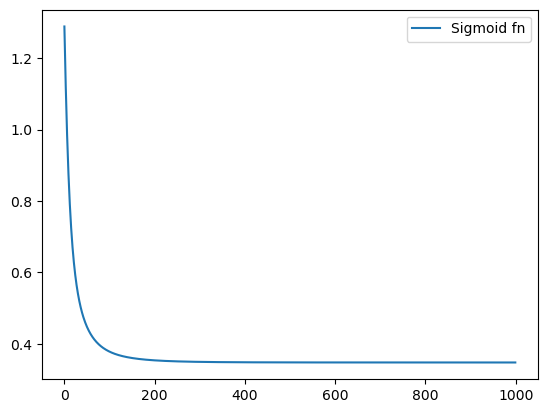

Accuracy : 0.8524590163934426
Precision : 0.8709677419354839
cost fn : [0.34824427]


In [ ]:
plt.plot(model.cost_function_values,label="Sigmoid fn")
plt.legend()
plt.show()
metrics = model.test_model()
print(f"Accuracy : {metrics[0]}")
print(f"Precision : {metrics[1]}")
print(f"Confusion Matrix : {metrics[2]}")
print(f"cost fn : {model.cost_function_values[-1:]}")